# MATH 5010 Computer Lab 1 — Basic Probability

**Section 1: Introduction to Probability Theory**  
**Instructor:** He Wang  
**Theme:** set operations, sample spaces, probability axioms, counting, conditional probability, independence, total probability, Bayes' theorem, simulation, and geometric probability.

This lab is written as a **full-solution notebook**. Every example and practice problem includes a complete worked solution using Python and mathematical explanation.

## Learning goals

By the end of this lab, you should be able to:

1. Represent finite sample spaces and events using Python sets.
2. Verify basic probability identities computationally.
3. Use counting rules to compute probabilities in equally likely finite sample spaces.
4. Use simulation to interpret probability as long-run relative frequency.
5. Compute conditional probabilities and check independence.
6. Apply the law of total probability and Bayes' theorem.
7. Approximate geometric probabilities using Monte Carlo simulation.


## 0. Setup

We import standard Python libraries. We will use exact fractions when possible so students can see exact answers before decimal approximations.


In [1]:
import itertools
import math
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(5010)

pd.set_option("display.precision", 4)
print("Setup complete.")


Matplotlib is building the font cache; this may take a moment.


Setup complete.


## 1. Set operations and events

In probability theory, an experiment has a **sample space** $S$, and an **event** is a subset of $S$.

The standard set operations are:

- complement: $A^c = S \setminus A$,
- union: $A \cup B$,
- intersection: $A \cap B$,
- difference: $A \setminus B$.

### Example 1.1: Two coin tosses

Let the experiment be tossing a fair coin twice. Let

$$
S = \{HH, HT, TH, TT\}.
$$

Define events:

$$
A = \{\text{first toss is H}\}, \qquad
B = \{\text{second toss is H}\}, \qquad
C = \{\text{the two tosses are the same}\}.
$$

We compute $A \cup B$, $A \cap B$, $A^c$, and $A \triangle B$, where $A \triangle B$ means exactly one of $A$ or $B$ occurs.


In [2]:
S = {"HH", "HT", "TH", "TT"}
A = {outcome for outcome in S if outcome[0] == "H"}
B = {outcome for outcome in S if outcome[1] == "H"}
C = {outcome for outcome in S if outcome[0] == outcome[1]}

results = {
    "S": S,
    "A = first toss H": A,
    "B = second toss H": B,
    "C = same outcomes": C,
    "A union B": A | B,
    "A intersection B": A & B,
    "A complement": S - A,
    "A symmetric difference B": (A - B) | (B - A),
}

for name, event in results.items():
    print(f"{name:28s}: {sorted(event)}")


S                           : ['HH', 'HT', 'TH', 'TT']
A = first toss H            : ['HH', 'HT']
B = second toss H           : ['HH', 'TH']
C = same outcomes           : ['HH', 'TT']
A union B                   : ['HH', 'HT', 'TH']
A intersection B            : ['HH']
A complement                : ['TH', 'TT']
A symmetric difference B    : ['HT', 'TH']


### Solution interpretation

- $A \cup B = \{HH, HT, TH\}$ means at least one toss is heads.
- $A \cap B = \{HH\}$ means both tosses are heads.
- $A^c = \{TH, TT\}$ means the first toss is not heads.
- $A \triangle B = \{HT, TH\}$ means exactly one toss is heads.


## 2. Probability on a finite sample space

If all outcomes in a finite sample space are equally likely, then

$$
P(A) = \frac{|A|}{|S|}.
$$

This is the classical counting definition of probability.

### Example 2.1: Verify basic probability identities

Using the events from the two-coin experiment, verify:

$$
P(A^c) = 1 - P(A),
$$

and

$$
P(A \cup B) = P(A) + P(B) - P(A \cap B).
$$


In [3]:
def prob(event, sample_space=S):
    '''Classical probability for equally likely finite outcomes.'''
    return Fraction(len(event), len(sample_space))

P_A = prob(A)
P_B = prob(B)
P_Ac = prob(S - A)
P_A_inter_B = prob(A & B)
P_A_union_B = prob(A | B)

summary = pd.DataFrame({
    "quantity": ["P(A)", "P(B)", "P(A^c)", "1 - P(A)", "P(A ∩ B)", "P(A ∪ B)", "P(A)+P(B)-P(A∩B)"],
    "exact": [P_A, P_B, P_Ac, 1 - P_A, P_A_inter_B, P_A_union_B, P_A + P_B - P_A_inter_B],
    "decimal": [float(x) for x in [P_A, P_B, P_Ac, 1 - P_A, P_A_inter_B, P_A_union_B, P_A + P_B - P_A_inter_B]],
})
summary


,quantity,exact,decimal
0,P(A),1/2,0.50
1,P(B),1/2,0.50
2,P(A^c),1/2,0.50
3,1 - P(A),1/2,0.50
4,P(A ∩ B),1/4,0.25
5,P(A ∪ B),3/4,0.75
6,P(A)+P(B)-P(A∩B),3/4,0.75


### Solution interpretation

The table verifies both identities exactly:

$$
P(A^c)=1-P(A)=\frac{1}{2},
$$

and

$$
P(A\cup B)=\frac{3}{4}=\frac{1}{2}+\frac{1}{2}-\frac{1}{4}.
$$


## 3. Practice: event formulas

Let $A$ and $B$ be events. Express each probability in terms of $P(A)$, $P(B)$, and $P(A \cap B)$:

1. either $A$ or $B$ or both,
2. either $A$ or $B$ but not both,
3. at least one of $A$ or $B$,
4. at most one of $A$ or $B$.

### Solution

1. Either $A$ or $B$ or both is $A \cup B$, so

$$
P(A \cup B)=P(A)+P(B)-P(A\cap B).
$$

2. Either $A$ or $B$ but not both is $(A\setminus B)\cup(B\setminus A)$, so

$$
P((A\setminus B)\cup(B\setminus A))=P(A)+P(B)-2P(A\cap B).
$$

3. At least one of $A$ or $B$ is again $A\cup B$, so

$$
P(\text{at least one})=P(A)+P(B)-P(A\cap B).
$$

4. At most one of $A$ or $B$ means not both, so

$$
P(\text{at most one})=P((A\cap B)^c)=1-P(A\cap B).
$$


In [4]:
# Numerical check using P(A)=0.6, P(B)=0.5, P(A∩B)=0.2.
PA = 0.6
PB = 0.5
PAB = 0.2

formula_check = pd.DataFrame({
    "event description": [
        "either A or B or both",
        "either A or B but not both",
        "at least one of A or B",
        "at most one of A or B",
    ],
    "formula value": [
        PA + PB - PAB,
        PA + PB - 2 * PAB,
        PA + PB - PAB,
        1 - PAB,
    ]
})
formula_check


,event description,formula value
0,either A or B or both,0.9
1,either A or B but not both,0.7
2,at least one of A or B,0.9
3,at most one of A or B,0.8


## 4. Counting rules

Important counting rules:

1. **Fundamental theorem of counting:** if one operation has $m$ choices and another has $n$ choices, then the ordered pair of operations has $mn$ choices.
2. **Permutation:** number of ordered arrangements of $k$ objects selected from $n$ distinct objects:

$$
P(n,k)=\frac{n!}{(n-k)!}.
$$

3. **Combination:** number of unordered subsets of $k$ objects selected from $n$ distinct objects:

$$
\binom{n}{k}=\frac{n!}{k!(n-k)!}.
$$

4. **With replacement and order matters:** $n^k$.
5. **With replacement and order does not matter:**

$$
\binom{n+k-1}{k}.
$$

### Example 4.1: Four counting scenarios

Suppose there are $n=5$ flavors and we select $k=3$ scoops/items.


In [5]:
n = 5
k = 3
counting_table = pd.DataFrame({
    "Replacement?": ["Yes", "No", "No", "Yes"],
    "Order matters?": ["Yes", "Yes", "No", "No"],
    "formula": ["n^k", "n!/(n-k)!", "C(n,k)", "C(n+k-1,k)"],
    "count": [n**k, math.factorial(n)//math.factorial(n-k), math.comb(n,k), math.comb(n+k-1,k)],
})
counting_table


,Replacement?,Order matters?,formula,count
0,Yes,Yes,n^k,125
1,No,Yes,n!/(n-k)!,60
2,No,No,"C(n,k)",10
3,Yes,No,"C(n+k-1,k)",35


### Solution interpretation

For $n=5$ and $k=3$:

- with replacement and order matters: $5^3=125$,
- without replacement and order matters: $5\cdot 4\cdot 3=60$,
- without replacement and order does not matter: $\binom{5}{3}=10$,
- with replacement and order does not matter: $\binom{5+3-1}{3}=35$.


## 5. Birthday paradox

The birthday paradox is a classical probability example where using the complement is easier.

For $n$ people and 365 equally likely birthdays, the probability that all birthdays are different is

$$
P(\text{all different}) = \frac{365}{365}\cdot\frac{364}{365}\cdots \frac{365-n+1}{365}.
$$

Therefore,

$$
P(\text{at least one shared birthday})=1-P(\text{all different}).
$$

### Example 5.1: $n=3$ and $n=30$


In [6]:
def prob_all_different_birthdays(n, days=365):
    if n > days:
        return 0.0
    p = 1.0
    for i in range(n):
        p *= (days - i) / days
    return p

def prob_at_least_one_shared_birthday(n, days=365):
    return 1 - prob_all_different_birthdays(n, days)

for n_people in [3, 23, 30, 50]:
    print(f"n = {n_people:2d}: P(all different) = {prob_all_different_birthdays(n_people):.4f}, "
          f"P(at least one match) = {prob_at_least_one_shared_birthday(n_people):.4f}")


n =  3: P(all different) = 0.9918, P(at least one match) = 0.0082
n = 23: P(all different) = 0.4927, P(at least one match) = 0.5073
n = 30: P(all different) = 0.2937, P(at least one match) = 0.7063
n = 50: P(all different) = 0.0296, P(at least one match) = 0.9704


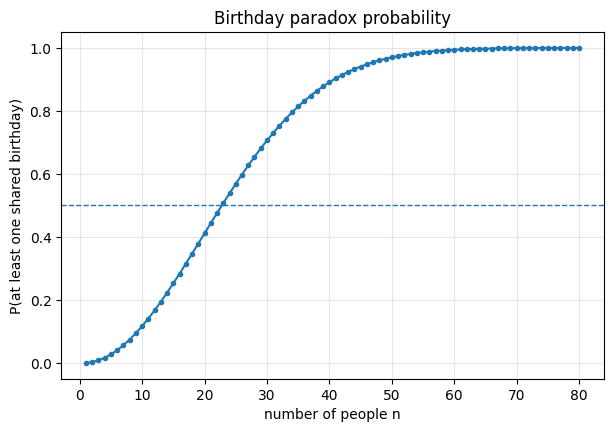

In [7]:
# Plot the birthday probability curve.
ns = np.arange(1, 81)
probs = np.array([prob_at_least_one_shared_birthday(int(n)) for n in ns])

plt.figure(figsize=(7, 4.5))
plt.plot(ns, probs, marker="o", markersize=3)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xlabel("number of people n")
plt.ylabel("P(at least one shared birthday)")
plt.title("Birthday paradox probability")
plt.grid(True, alpha=0.3)
plt.show()


### Solution interpretation

For $n=3$,

$$
P(\text{all different})=\frac{365\cdot 364\cdot 363}{365^3}\approx 0.9918.
$$

For $n=30$,

$$
P(\text{at least one shared birthday})
=1-\frac{365\cdot 364\cdots 336}{365^{30}}
\approx 0.7063.
$$

This is surprisingly large: with only 30 people, there is about a 70.6% chance of at least one birthday match.


## 6. Frequency interpretation of probability

The frequentist interpretation views probability as a long-run relative frequency under repeated identical trials.

### Example 6.1: Simulating coin tosses

We simulate many fair coin tosses and track the running proportion of heads.


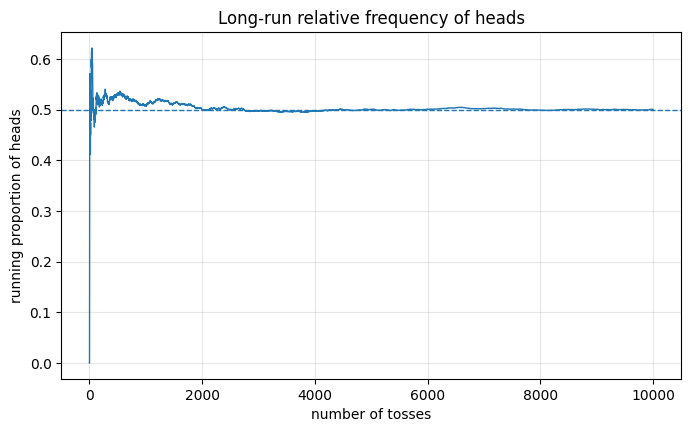

Final proportion of heads after 10000 tosses: 0.5009


In [8]:
N = 10_000
coin_tosses = rng.integers(0, 2, size=N)   # 1 = Head, 0 = Tail
running_heads = np.cumsum(coin_tosses) / np.arange(1, N + 1)

plt.figure(figsize=(8, 4.5))
plt.plot(running_heads, linewidth=1)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xlabel("number of tosses")
plt.ylabel("running proportion of heads")
plt.title("Long-run relative frequency of heads")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final proportion of heads after {N} tosses: {running_heads[-1]:.4f}")


### Solution interpretation

The running proportion is not exactly $0.5$ for finite samples, but it tends to get close to $0.5$ as the number of tosses increases. This illustrates the frequency interpretation of probability.


## 7. Conditional probability

For events $A$ and $B$ with $P(B)>0$, the conditional probability of $A$ given $B$ is

$$
P(A|B)=\frac{P(A\cap B)}{P(B)}.
$$

### Example 7.1: One die roll

Roll a fair six-sided die once. Given that the result is even, what is the probability that the result is 6?

Let

$$
B = \{2,4,6\}, \qquad A = \{6\}.
$$

Then $A\cap B=A$.


In [9]:
die = set(range(1, 7))
A = {6}
B = {2, 4, 6}

P_A_given_B = prob(A & B, die) / prob(B, die)
print("P(A | B) =", P_A_given_B, "=", float(P_A_given_B))


P(A | B) = 1/3 = 0.3333333333333333


### Solution

$$
P(A|B)=\frac{P(A\cap B)}{P(B)}
=\frac{1/6}{3/6}
=\frac{1}{3}.
$$


## 8. Independence

Events $A$ and $B$ are independent if

$$
P(A\cap B)=P(A)P(B).
$$

Equivalently, when $P(B)>0$,

$$
P(A|B)=P(A).
$$

### Example 8.1: Two dice

Roll a fair six-sided die twice. Let

$$
A = \{\text{first die is even}\}, \qquad B = \{\text{second die is 6}\}.
$$

Check whether $A$ and $B$ are independent.


In [10]:
dice2 = list(itertools.product(range(1, 7), range(1, 7)))
S_dice2 = set(dice2)
A = {outcome for outcome in S_dice2 if outcome[0] % 2 == 0}
B = {outcome for outcome in S_dice2 if outcome[1] == 6}

P_A = prob(A, S_dice2)
P_B = prob(B, S_dice2)
P_AB = prob(A & B, S_dice2)

pd.DataFrame({
    "quantity": ["P(A)", "P(B)", "P(A∩B)", "P(A)P(B)"],
    "exact": [P_A, P_B, P_AB, P_A * P_B],
    "decimal": [float(P_A), float(P_B), float(P_AB), float(P_A * P_B)]
})


,quantity,exact,decimal
0,P(A),1/2,0.5000
1,P(B),1/6,0.1667
2,P(A∩B),1/12,0.0833
3,P(A)P(B),1/12,0.0833


### Solution

Here

$$
P(A)=\frac{3}{6}=\frac12, \qquad P(B)=\frac16,
$$

and

$$
P(A\cap B)=\frac{3}{36}=\frac{1}{12}.
$$

Since

$$
P(A)P(B)=\frac12\cdot\frac16=\frac{1}{12}=P(A\cap B),
$$

$A$ and $B$ are independent.


## 9. Practice: independence of coin-toss events

A fair coin is tossed twice. Let

$$
A=\{\text{first toss is Head}\}, \qquad
C=\{\text{the two tosses are the same}\}.
$$

Check if $A$ and $C$ are independent.

### Solution


In [11]:
S = {"HH", "HT", "TH", "TT"}
A = {outcome for outcome in S if outcome[0] == "H"}
C = {outcome for outcome in S if outcome[0] == outcome[1]}

P_A = prob(A, S)
P_C = prob(C, S)
P_AC = prob(A & C, S)

print("A =", sorted(A))
print("C =", sorted(C))
print("A ∩ C =", sorted(A & C))
print("P(A)P(C) =", P_A * P_C)
print("P(A ∩ C) =", P_AC)
print("Independent?", P_AC == P_A * P_C)


A = ['HH', 'HT']
C = ['HH', 'TT']
A ∩ C = ['HH']
P(A)P(C) = 1/4
P(A ∩ C) = 1/4
Independent? True


Because

$$
P(A)=\frac12, \qquad P(C)=\frac12, \qquad P(A\cap C)=P(\{HH\})=\frac14,
$$

we have

$$
P(A\cap C)=P(A)P(C).
$$

Therefore $A$ and $C$ are independent.


## 10. Law of total probability

If $A_1,\ldots,A_n$ form a partition of the sample space $S$, then for any event $B$,

$$
P(B)=\sum_{i=1}^n P(B|A_i)P(A_i).
$$

### Example 10.1: Medical test, overall positive probability

In a population, 1% of people have a disease. The test gives a positive result with probability 0.95 if the person has the disease, and 0.10 if the person does not have the disease.

Find the overall probability that the test result is positive.


In [12]:
P_D = 0.01
P_not_D = 1 - P_D
P_pos_given_D = 0.95
P_pos_given_not_D = 0.10

P_pos = P_pos_given_D * P_D + P_pos_given_not_D * P_not_D
print(f"P(positive) = {P_pos:.4f}")


P(positive) = 0.1085


### Solution

Let $T$ be the event that the test is positive, and let $D$ be the event that the person has the disease. Then

$$
P(T)=P(T|D)P(D)+P(T|D^c)P(D^c).
$$

Therefore

$$
P(T)=0.95(0.01)+0.10(0.99)=0.1085.
$$

So the overall probability of a positive test is **0.1085**.


### Example 10.2: Commute and lateness

In a city, 30% of people use bus, 50% use subway, and 20% drive. The probabilities of being late are 0.10 for bus users, 0.05 for subway users, and 0.20 for drivers.

Find the probability that a randomly selected person is late.


In [13]:
commute = pd.DataFrame({
    "method": ["Bus", "Subway", "Drive"],
    "P(method)": [0.30, 0.50, 0.20],
    "P(late | method)": [0.10, 0.05, 0.20],
})
commute["contribution"] = commute["P(method)"] * commute["P(late | method)"]
P_late = commute["contribution"].sum()

commute, P_late


(   method  P(method)  P(late | method)  contribution
 0     Bus        0.3              0.10         0.030
 1  Subway        0.5              0.05         0.025
 2   Drive        0.2              0.20         0.040,
 np.float64(0.095))

### Solution

Let $L$ be the event late. Then

$$
P(L)=P(L|B)P(B)+P(L|S)P(S)+P(L|C)P(C).
$$

Thus

$$
P(L)=0.10(0.30)+0.05(0.50)+0.20(0.20)=0.095.
$$


## 11. Bayes' theorem

Bayes' theorem reverses conditioning:

$$
P(A_i|B)=\frac{P(B|A_i)P(A_i)}{\sum_j P(B|A_j)P(A_j)}.
$$

### Example 11.1: Factory machines

A factory has two machines:

- Machine I produces 40% of parts, defect rate 1%.
- Machine II produces 60% of parts, defect rate 2%.

A randomly chosen part is defective. What is the probability that it came from Machine I?


In [14]:
P_I = 0.40
P_II = 0.60
P_D_given_I = 0.01
P_D_given_II = 0.02

P_D = P_D_given_I * P_I + P_D_given_II * P_II
P_I_given_D = P_D_given_I * P_I / P_D

print(f"P(D) = {P_D:.4f}")
print(f"P(I | D) = {P_I_given_D:.4f}")


P(D) = 0.0160
P(I | D) = 0.2500


### Solution

Let $D$ be the event defective. Then

$$
P(I|D)=\frac{P(D|I)P(I)}{P(D|I)P(I)+P(D|II)P(II)}.
$$

Substitute values:

$$
P(I|D)=\frac{0.01\cdot 0.40}{0.01\cdot 0.40+0.02\cdot 0.60}
=\frac{0.004}{0.016}
=0.25.
$$

So the probability is **0.25**.


### Example 11.2: Bayesian updating with five heads in a row

Suppose someone claims they can toss a coin so that it always comes up heads. You are 95% sure they are lying before seeing evidence.

Let:

- $L$: the person is lying and the coin is fair, so $P(H)=1/2$,
- $T$: the person is telling the truth and heads occurs with probability 1.

Prior probabilities:

$$
P(L)=0.95, \qquad P(T)=0.05.
$$

You observe five heads in a row. Compute $P(L|HHHHH)$.


In [15]:
P_L = 0.95
P_T = 0.05
P_data_given_L = (1/2)**5
P_data_given_T = 1.0

P_data = P_data_given_L * P_L + P_data_given_T * P_T
P_L_given_data = P_data_given_L * P_L / P_data
P_T_given_data = P_data_given_T * P_T / P_data

print(f"P(L | five heads) = {P_L_given_data:.4f}")
print(f"P(T | five heads) = {P_T_given_data:.4f}")


P(L | five heads) = 0.3725
P(T | five heads) = 0.6275


### Solution

Using Bayes' theorem,

$$
P(L|H^5)=\frac{P(H^5|L)P(L)}{P(H^5|L)P(L)+P(H^5|T)P(T)}.
$$

Since $P(H^5|L)=(1/2)^5$ and $P(H^5|T)=1$,

$$
P(L|H^5)
=\frac{(1/2)^5(0.95)}{(1/2)^5(0.95)+1(0.05)}
\approx 0.3725.
$$

After observing five heads, the posterior probability that the person is lying drops from 0.95 to about **0.3725**.


## 12. Monty Hall problem

There are three doors. One door has a prize, and two doors do not. You choose one door. The host, who knows where the prize is, opens another door with no prize. You can either stay with your original choice or switch.

Should you switch?

### Simulation solution


In [16]:
def simulate_monty_hall(num_games=100_000, switch=True, rng=rng):
    wins = 0
    for _ in range(num_games):
        prize = rng.integers(0, 3)
        first_choice = rng.integers(0, 3)
        possible_open = [door for door in range(3) if door != first_choice and door != prize]
        opened = rng.choice(possible_open)
        if switch:
            final_choice = [door for door in range(3) if door != first_choice and door != opened][0]
        else:
            final_choice = first_choice
        wins += (final_choice == prize)
    return wins / num_games

stay_win = simulate_monty_hall(switch=False)
switch_win = simulate_monty_hall(switch=True)

print(f"Win probability if staying:   {stay_win:.4f}")
print(f"Win probability if switching: {switch_win:.4f}")


Win probability if staying:   0.3322
Win probability if switching: 0.6663


### Mathematical solution

Your original choice is correct with probability $1/3$ and incorrect with probability $2/3$.

- If your original choice is correct, switching loses.
- If your original choice is incorrect, switching wins because the host reveals the other losing door.

Therefore

$$
P(\text{win by staying})=\frac13,
$$

and

$$
P(\text{win by switching})=\frac23.
$$

So you should **switch**.


## 13. Conditional independence

Events $A$ and $B$ are conditionally independent given $C$ if

$$
P(A\cap B|C)=P(A|C)P(B|C).
$$

Conditional independence and ordinary independence are different concepts. One does not automatically imply the other.

### Example 13.1: Conditional independence can hold even when ordinary independence fails

Let there be two groups. First choose group $C\in\{0,1\}$. Given the group, generate two independent Bernoulli outcomes $A$ and $B$ with the same group-dependent probability:

$$
P(A=1|C=0)=P(B=1|C=0)=0.2,
$$

$$
P(A=1|C=1)=P(B=1|C=1)=0.8.
$$

Given $C$, the variables are independent. But marginally, $A$ and $B$ are positively associated because the group affects both.


In [17]:
N = 200_000
C = rng.integers(0, 2, size=N)
p = np.where(C == 0, 0.2, 0.8)
A = rng.binomial(1, p)
B = rng.binomial(1, p)

P_A = A.mean()
P_B = B.mean()
P_AB = np.mean((A == 1) & (B == 1))

rows = []
for c in [0, 1]:
    mask = C == c
    rows.append({
        "C": c,
        "P(A=1 | C)": A[mask].mean(),
        "P(B=1 | C)": B[mask].mean(),
        "P(A=1,B=1 | C)": np.mean((A[mask] == 1) & (B[mask] == 1)),
        "product": A[mask].mean() * B[mask].mean(),
    })

print("Marginal probabilities:")
print(f"P(A=1)P(B=1) = {P_A * P_B:.4f}")
print(f"P(A=1, B=1) = {P_AB:.4f}")
print()
print("Conditional checks:")
pd.DataFrame(rows)


Marginal probabilities:
P(A=1)P(B=1) = 0.2491
P(A=1, B=1) = 0.3396

Conditional checks:


,C,P(A=1 | C),P(B=1 | C),"P(A=1,B=1 | C)",product
0,0,0.2010,0.1981,0.0403,0.0398
1,1,0.7991,0.7995,0.6395,0.6390


### Solution interpretation

Given each value of $C$, the joint probability is approximately the product of the conditional probabilities:

$$
P(A=1,B=1|C=c)\approx P(A=1|C=c)P(B=1|C=c).
$$

However, marginally,

$$
P(A=1,B=1) \neq P(A=1)P(B=1).
$$

Thus $A$ and $B$ are conditionally independent given $C$, but they are not marginally independent.


## 14. Geometric probability

When a point is chosen uniformly from a region, probability equals area ratio.

### Example 14.1: Unit square probability

Let $(X,Y)$ be chosen uniformly at random in the unit square $[0,1]^2$. Compute

$$
P(X^2+Y\leq 1).
$$

The event is

$$
\{(x,y):0\leq x\leq 1,\ 0\leq y\leq 1-x^2\}.
$$

Thus the exact probability is the area

$$
\int_0^1 (1-x^2)\,dx=\frac23.
$$

Now verify by simulation.


In [18]:
N = 200_000
X = rng.random(N)
Y = rng.random(N)
inside = X**2 + Y <= 1
p_hat = inside.mean()
exact = 2/3
print(f"Monte Carlo estimate: {p_hat:.5f}")
print(f"Exact value:          {exact:.5f}")
print(f"Absolute error:       {abs(p_hat - exact):.5f}")


Monte Carlo estimate: 0.66631
Exact value:          0.66667
Absolute error:       0.00036


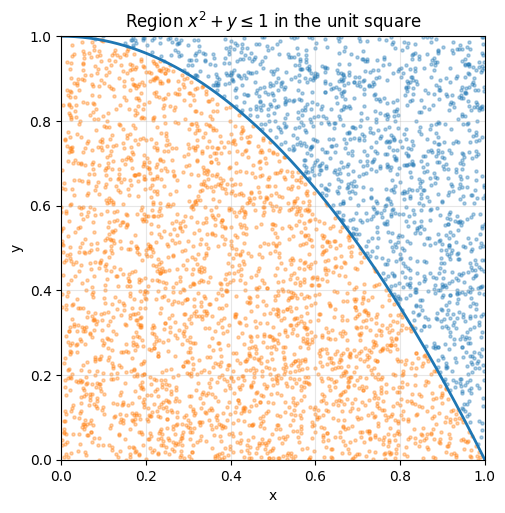

In [19]:
# Visualization of the region.
N_plot = 4000
X_plot = rng.random(N_plot)
Y_plot = rng.random(N_plot)
inside_plot = X_plot**2 + Y_plot <= 1

x_curve = np.linspace(0, 1, 300)
y_curve = 1 - x_curve**2

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X_plot[~inside_plot], Y_plot[~inside_plot], s=5, alpha=0.35)
plt.scatter(X_plot[inside_plot], Y_plot[inside_plot], s=5, alpha=0.35)
plt.plot(x_curve, y_curve, linewidth=2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Region $x^2+y\leq 1$ in the unit square")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.show()


### Solution

Since the distribution is uniform over $[0,1]^2$, the probability equals the area of the region:

$$
P(X^2+Y\leq 1)=\int_0^1 (1-x^2)\,dx
=\left[x-\frac{x^3}{3}\right]_0^1
=1-\frac13
=\frac23.
$$


## 15. Binomial identity from a probability problem

Two people each toss a fair coin $n$ times. Let

$$
X = \text{number of heads for person 1}, \qquad
Y = \text{number of heads for person 2}.
$$

Then $X,Y\sim\text{Binomial}(n,1/2)$ independently. Find

$$
P(X=Y).
$$

### Solution

Since $X$ and $Y$ are independent,

$$
P(X=Y)=\sum_{k=0}^n P(X=k)P(Y=k).
$$

Since

$$
P(X=k)=\binom{n}{k}\left(\frac12\right)^n,
$$

we get

$$
P(X=Y)=\sum_{k=0}^n \binom{n}{k}^2\left(\frac14\right)^n.
$$

Using the identity

$$
\sum_{k=0}^n \binom{n}{k}^2=\binom{2n}{n},
$$

we obtain

$$
P(X=Y)=\frac{\binom{2n}{n}}{4^n}.
$$


In [20]:
def prob_equal_heads(n):
    return math.comb(2*n, n) / 4**n

values = pd.DataFrame({
    "n": list(range(1, 16)),
    "P(X=Y)": [prob_equal_heads(n) for n in range(1, 16)],
})
values


,n,P(X=Y)
0,1,0.5000
1,2,0.3750
2,3,0.3125
3,4,0.2734
4,5,0.2461
5,6,0.2256
6,7,0.2095
7,8,0.1964
8,9,0.1855
9,10,0.1762


## 16. Practice set with full solutions

This section gives a compact lab-style practice set. The code cells are complete solutions.


### Practice 16.1: Set identities by simulation on a finite sample space

Roll a die twice. Let

$$
A=\{\text{sum is at least 8}\}, \quad
B=\{\text{first die is 6}\}.
$$

Compute $P(A)$, $P(B)$, $P(A\cap B)$, $P(A\cup B)$, and check inclusion-exclusion.


In [21]:
S = set(itertools.product(range(1, 7), range(1, 7)))
A = {s for s in S if sum(s) >= 8}
B = {s for s in S if s[0] == 6}

answer = pd.DataFrame({
    "quantity": ["P(A)", "P(B)", "P(A∩B)", "P(A∪B)", "P(A)+P(B)-P(A∩B)"],
    "exact": [prob(A, S), prob(B, S), prob(A & B, S), prob(A | B, S), prob(A, S)+prob(B, S)-prob(A & B, S)],
})
answer["decimal"] = answer["exact"].apply(float)
answer


,quantity,exact,decimal
0,P(A),5/12,0.4167
1,P(B),1/6,0.1667
2,P(A∩B),5/36,0.1389
3,P(A∪B),4/9,0.4444
4,P(A)+P(B)-P(A∩B),4/9,0.4444


### Practice 16.2: Conditional probability and independence

Using the same $A$ and $B$, compute $P(A|B)$ and decide whether $A$ and $B$ are independent.


In [22]:
P_A_given_B = prob(A & B, S) / prob(B, S)
P_A = prob(A, S)
P_B = prob(B, S)
P_AB = prob(A & B, S)

print("P(A | B) =", P_A_given_B, "=", float(P_A_given_B))
print("P(A)     =", P_A, "=", float(P_A))
print("P(A∩B)   =", P_AB)
print("P(A)P(B) =", P_A * P_B)
print("Independent?", P_AB == P_A * P_B)


P(A | B) = 5/6 = 0.8333333333333334
P(A)     = 5/12 = 0.4166666666666667
P(A∩B)   = 5/36
P(A)P(B) = 5/72
Independent? False


### Solution interpretation

Since $P(A|B)\neq P(A)$ and $P(A\cap B)\neq P(A)P(B)$, the events are **not independent**.


### Practice 16.3: Bayes theorem for medical testing

Using the medical-test example, compute the probability that a person actually has the disease given that the test is positive.


In [23]:
P_D = 0.01
P_T_given_D = 0.95
P_T_given_not_D = 0.10
P_T = P_T_given_D * P_D + P_T_given_not_D * (1 - P_D)
P_D_given_T = P_T_given_D * P_D / P_T
print(f"P(D | positive) = {P_D_given_T:.4f}")


P(D | positive) = 0.0876


### Solution

$$
P(D|T)=\frac{P(T|D)P(D)}{P(T|D)P(D)+P(T|D^c)P(D^c)}.
$$

Thus

$$
P(D|T)=\frac{0.95(0.01)}{0.95(0.01)+0.10(0.99)}\approx 0.0876.
$$

Even after a positive test, the probability of disease is only about **8.76%**, because the disease is rare and the false positive rate is non-negligible.


### Practice 16.4: Monte Carlo estimate of a probability

Estimate

$$
P(X+Y\leq 1)
$$

where $(X,Y)$ is uniform on $[0,1]^2$. Compare with the exact answer.


In [24]:
N = 100_000
X = rng.random(N)
Y = rng.random(N)
p_hat = np.mean(X + Y <= 1)
exact = 1/2

print(f"Monte Carlo estimate: {p_hat:.4f}")
print(f"Exact area:           {exact:.4f}")


Monte Carlo estimate: 0.4980
Exact area:           0.5000


### Solution

The event $X+Y\leq 1$ is the lower-left triangle in the unit square, whose area is

$$
\frac12\cdot 1\cdot 1=\frac12.
$$

So the exact probability is $1/2$.


## 17. Summary

In this lab we used Python to study the basic building blocks of probability:

- sample spaces and events,
- set operations,
- probability identities from Kolmogorov's axioms,
- finite counting probabilities,
- birthday paradox computations,
- simulation and long-run frequency,
- conditional probability,
- independence and conditional independence,
- law of total probability,
- Bayes' theorem,
- Monty Hall simulation,
- geometric probability.

The key message is that probability can be studied in three complementary ways:

1. **Symbolically**, using formulas and identities.
2. **Computationally**, using exact enumeration for finite sample spaces.
3. **Empirically**, using simulation to approximate long-run behavior.
